<a href="https://colab.research.google.com/github/surajkrpirari2007/surajkasdj/blob/main/dibities_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

data=pd.read_csv("diabetes_risk.csv")
data
data1=data.copy()

data1.columns
data1.head(5)
data1.drop(columns=['patient_id','city','income_bracket'],inplace=True)
data1['smoking_status'].fillna(data1['smoking_status'].mode()[0],inplace=True)
data1['alcohol_consumption'].fillna(data1['alcohol_consumption'].mode()[0],inplace=True)
data1.info()
data1.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       15000 non-null  int64  
 1   gender                    15000 non-null  object 
 2   bmi                       15000 non-null  float64
 3   family_history_diabetes   15000 non-null  object 
 4   physical_activity_level   15000 non-null  object 
 5   diet_type                 15000 non-null  object 
 6   smoking_status            15000 non-null  object 
 7   alcohol_consumption       15000 non-null  object 
 8   hours_sleep_per_night     15000 non-null  float64
 9   stress_level              15000 non-null  int64  
 10  fasting_blood_sugar       15000 non-null  int64  
 11  hba1c_level               15000 non-null  float64
 12  blood_pressure_systolic   15000 non-null  int64  
 13  blood_pressure_diastolic  15000 non-null  int64  
 14  waist_

,age,gender,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,diabetes_risk
0,47,Female,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,Low
1,53,Female,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low
2,47,Male,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,High
3,41,Male,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Low
4,57,Female,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,Low
5,58,Male,22.0,No,Active,Non-Vegetarian,Never,Occasional,6.9,6,148,6.3,148,100,98.0,Low
6,42,Female,22.5,No,Sedentary,Non-Vegetarian,Never,Never,7.0,10,190,7.5,140,81,95.0,Moderate
7,42,Female,19.5,No,Active,Non-Vegetarian,Never,Never,6.0,7,270,8.9,136,80,89.9,High
8,57,Male,20.3,Yes,Moderate,Non-Vegetarian,Current,Never,4.8,10,186,7.4,170,91,92.3,Moderate
9,44,Male,24.1,No,Moderate,Non-Vegetarian,Current,Occasional,6.2,8,178,7.6,150,90,102.5,Moderate


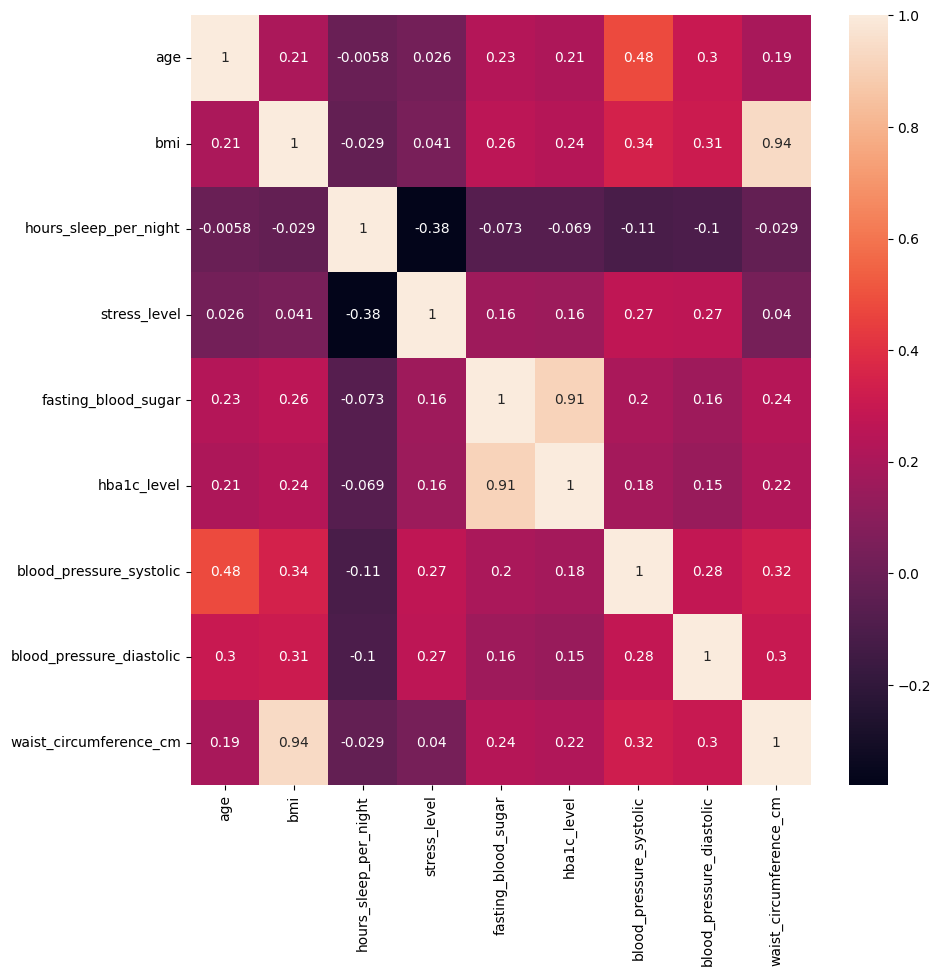

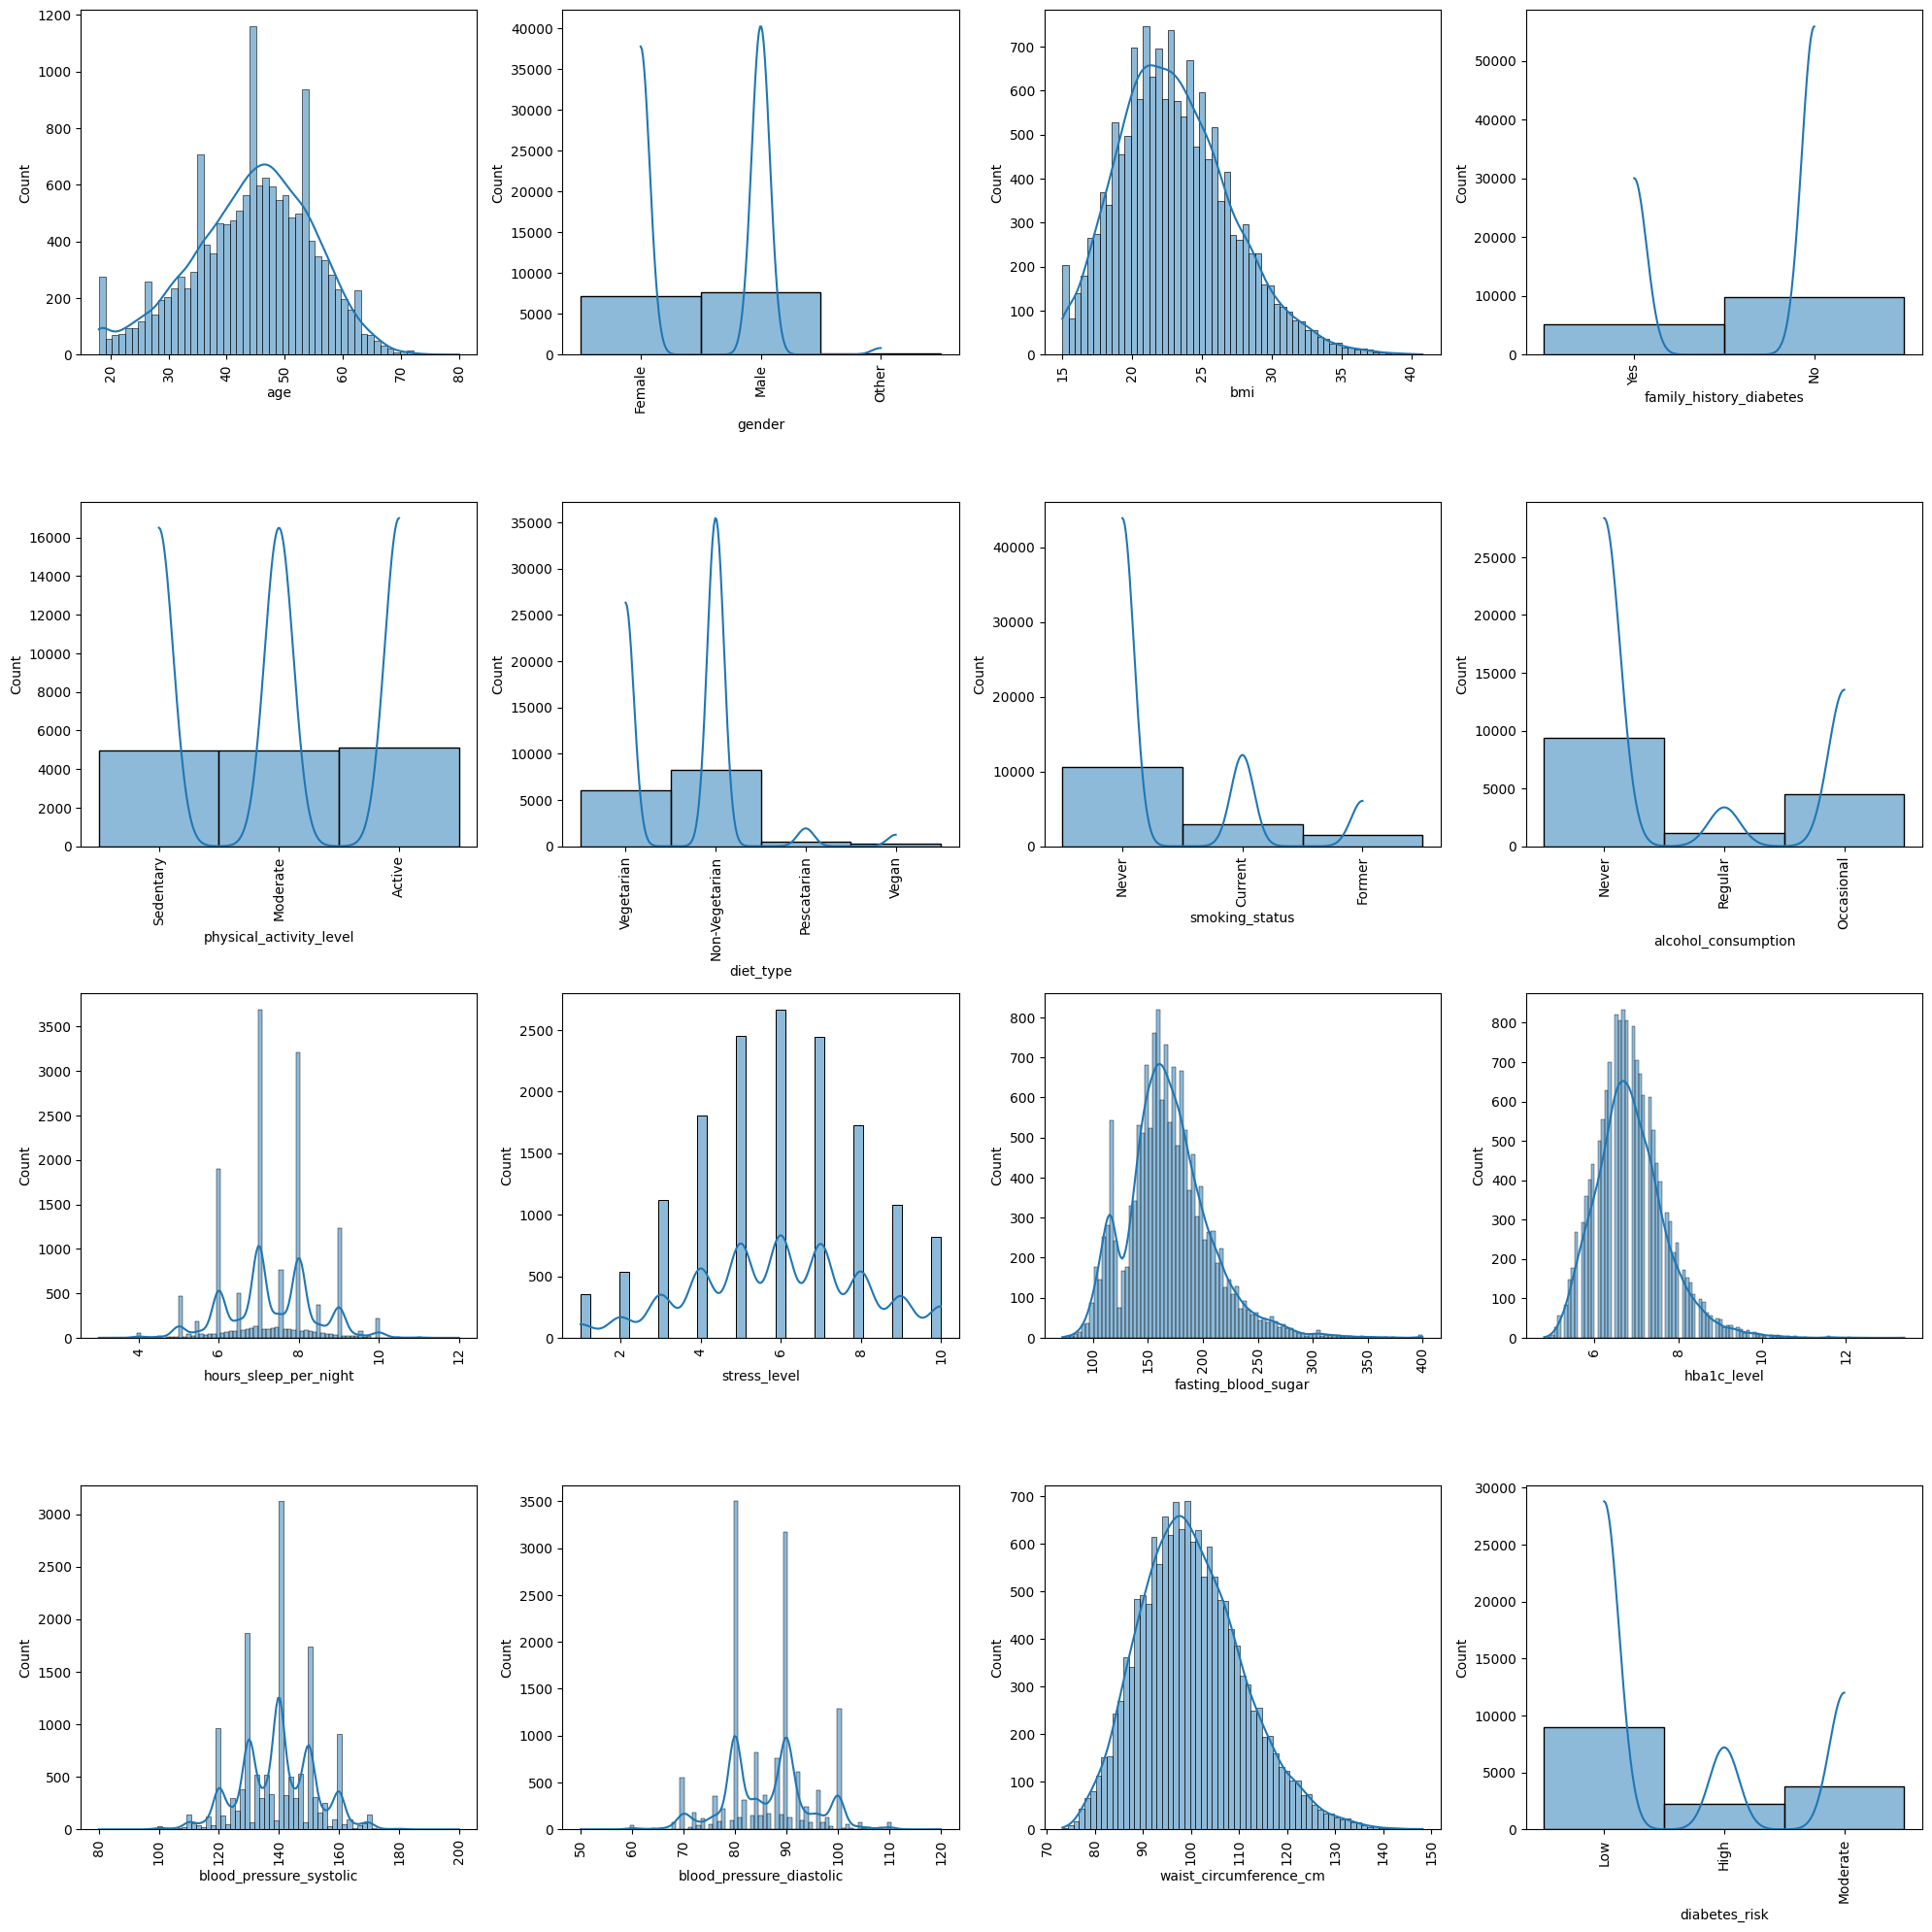

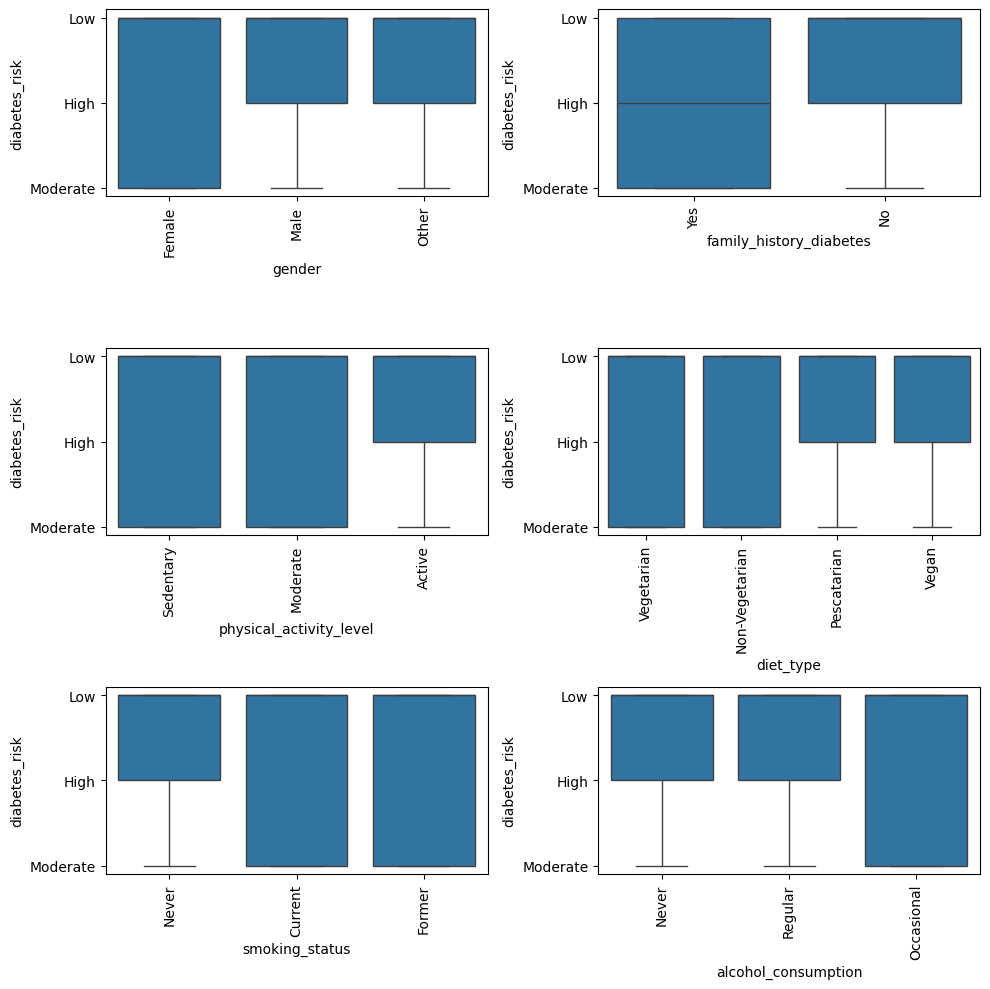

In [4]:
plt.figure(figsize=(10,10))
sns.heatmap(data1.corr(numeric_only=True),annot=True)

list_col=data1.columns
plt.figure(figsize=(20,20))
count=1
for col in list_col:
  plt.subplot(4,4,count)
  sns.histplot(data1[col],kde=True)
  plt.xticks(rotation=90)
  plt.tight_layout()
  count+=1
plt.show()

cat_col=[
    'gender','family_history_diabetes',
    'physical_activity_level','diet_type',
    'smoking_status','alcohol_consumption'
         ]
plt.figure(figsize=(10,10))
count1=1
for col1 in cat_col:
  plt.subplot(3,2,count1)
  sns.boxplot(y=data1['diabetes_risk'],x=data1[col1])
  plt.xticks(rotation=90)
  plt.tight_layout()
  count1+=1
plt.show()


In [5]:
data1['gender'].replace("Other",data1['gender'].mode()[0],inplace=True)
data1['gender'].value_counts()
data1.columns
data1['gender']=data1['gender'].map({'Female':0,'Male':1})
data1['family_history_diabetes']=data1['family_history_diabetes'].map({'No':0,'Yes':1})
x=data1.drop(columns=['diabetes_risk'])
y=data1['diabetes_risk']
x=pd.get_dummies(x)
x=x.astype('float')
x


,age,gender,bmi,family_history_diabetes,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,...,diet_type_Non-Vegetarian,diet_type_Pescatarian,diet_type_Vegan,diet_type_Vegetarian,smoking_status_Current,smoking_status_Former,smoking_status_Never,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular
0,47.0,0.0,26.5,1.0,9.0,8.0,178.0,7.3,146.0,90.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,53.0,0.0,20.5,1.0,7.0,6.0,152.0,6.9,156.0,100.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,47.0,1.0,31.3,0.0,7.0,7.0,168.0,6.6,150.0,102.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,41.0,1.0,22.8,0.0,9.0,5.0,155.0,6.7,126.0,92.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,57.0,0.0,16.7,0.0,6.5,10.0,188.0,6.7,130.0,90.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,47.0,1.0,37.7,0.0,6.8,7.0,213.0,8.1,150.0,100.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
14996,48.0,0.0,20.6,0.0,6.0,8.0,162.0,6.5,132.0,80.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
14997,34.0,0.0,17.9,0.0,7.0,6.0,137.0,6.5,136.0,90.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
14998,56.0,1.0,20.7,1.0,6.0,5.0,163.0,6.9,140.0,87.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
sclar_list=[
    'age','bmi','hours_sleep_per_night','stress_level',
    'fasting_blood_sugar','hba1c_level','blood_pressure_systolic',
    'blood_pressure_diastolic','waist_circumference_cm'
    ]

x[sclar_list]=scaler.fit_transform(x[sclar_list])
x

,age,gender,bmi,family_history_diabetes,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,...,diet_type_Non-Vegetarian,diet_type_Pescatarian,diet_type_Vegan,diet_type_Vegetarian,smoking_status_Current,smoking_status_Former,smoking_status_Never,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular
0,0.256788,0.0,0.849610,1.0,1.523561,0.958324,0.240067,0.499987,0.513714,0.446334,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.834633,0.0,-0.633242,1.0,-0.279320,0.027370,-0.437642,0.025631,1.303580,1.638762,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.256788,1.0,2.035892,0.0,-0.279320,0.492847,-0.020590,-0.330136,0.829660,1.877248,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.321057,1.0,-0.064815,0.0,1.523561,-0.438107,-0.359445,-0.211547,-1.066020,0.684819,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,1.219863,0.0,-1.572382,0.0,-0.730041,1.889277,0.500724,-0.211547,-0.750073,0.446334,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,0.256788,1.0,3.617601,0.0,-0.459609,0.492847,1.152368,1.448700,0.829660,1.638762,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
14996,0.353095,0.0,-0.608528,0.0,-1.180761,0.958324,-0.176985,-0.448725,-0.592100,-0.746094,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
14997,-0.995210,0.0,-1.275811,0.0,-0.279320,0.027370,-0.828628,-0.448725,-0.276153,0.446334,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
14998,1.123555,1.0,-0.583814,1.0,-1.180761,-0.438107,-0.150919,0.025631,0.039793,0.088605,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


In [7]:
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.svm import SVC
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model_svm=SVC()
model_svm.fit(x_train,y_train)







SVC()

In [8]:
y_pred=model_svm.predict(x_test)
display(y_pred[:10])
display(y_test.head(10))
display(accuracy_score(y_test,y_pred))
display(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

array(['Low', 'Moderate', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low',
       'Moderate'], dtype=object)

,diabetes_risk
11499,Low
6475,High
13167,Low
862,Low
5970,Low
6706,Low
3017,Low
3781,Low
3898,Moderate
2250,Low


0.7956666666666666

array([[ 305,   11,  116],
       [   4, 1668,  147],
       [  55,  280,  414]])

              precision    recall  f1-score   support

        High       0.84      0.71      0.77       432
         Low       0.85      0.92      0.88      1819
    Moderate       0.61      0.55      0.58       749

    accuracy                           0.80      3000
   macro avg       0.77      0.73      0.74      3000
weighted avg       0.79      0.80      0.79      3000



In [9]:
score=cross_val_score(model_svm,x,y,cv=5)
print(score)

[0.78466667 0.79066667 0.795      0.794      0.78766667]


In [10]:
grid_score=GridSearchCV((model_svm),
                        {
                            'C':[1,10,20],
                            'kernel':['rbf','linear'],
                            'degree':[3,6,8]
                            ,'gamma':['scale','auto']
                        },cv=5,return_train_score=False
                        )
grid_score.fit(x,y)
result=pd.DataFrame(grid_score.cv_results_)
result

KeyboardInterrupt: 